In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

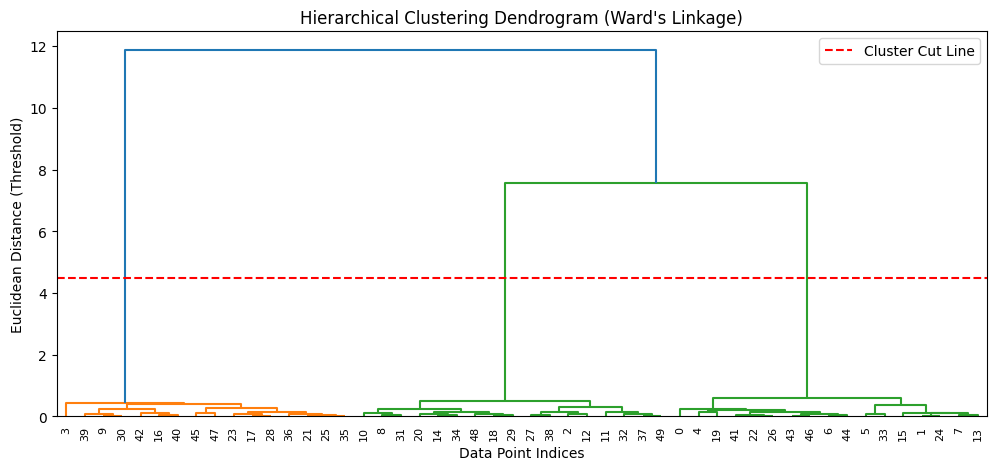

=== Hierarchical Clustering Output ===
First 10 Assigned Cluster Labels: [0 0 2 1 0 0 0 0 2 1]


In [1]:
#Topic 133 | Introduction to Hierarchical Clustering
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Dataset generate karein (Naturally 3 groups)
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=42)

# Distance-based algorithm hai, isliye scaling zaroori hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------
# STEP 2: SciPy ka use karte hue Dendrogram Plot Karein
# ------------------------------------------------------------------
# Hum Ward's linkage method use kar rahe hain matrix generate karne ke liye
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Data Point Indices")
plt.ylabel("Euclidean Distance (Threshold)")
plt.axhline(y=4.5, color="r", linestyle="--", label="Cluster Cut Line")
plt.legend()
plt.show()

# ------------------------------------------------------------------
# STEP 3: Scikit-Learn ke sath Final Cluster Labels Assign Karein
# ------------------------------------------------------------------
# Dendrogram dekh kar agar hum threshold set karein, toh humein 3 clusters milte hain
agg_cluster = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
labels = agg_cluster.fit_predict(X_scaled)

print("=== Hierarchical Clustering Output ===")
print(f"First 10 Assigned Cluster Labels: {labels[:10]}")

In [3]:
# Topic 134 | Hierarchical Clustering - Agglomerative vs Divisive Methods
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage  # Fixed: removed tree_to_labels
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# 1. Chota synthetic dataset generate karein (Sirf 6 points taake trace karna aasan ho)
X, _ = make_blobs(n_samples=6, centers=2, n_features=2, random_state=42)

print("=== DATA POINTS COORDINATES ===")
for idx, point in enumerate(X):
    print(f"Point {idx}: [{point[0]:.2f}, {point[1]:.2f}]")
print("-" * 50)

# ------------------------------------------------------------------
# APPROACH: Agglomerative Bottom-Up Linkage Tracking
# ------------------------------------------------------------------
# SciPy ka linkage function humein batata hai kaunse points kis step par merge huay
Z = linkage(X, method="ward")

print("\n=== AGGLOMERATIVE MERGE HISTORY (Bottom-Up) ===")
# Linkage matrix format: [Cluster A, Cluster B, Distance, New Cluster Size]
for i, step in enumerate(Z):
    print(
        f"Step {i+1}: Cluster {int(step[0])} aur Cluster {int(step[1])} aapas mein merge huay. "
        f"Distance: {step[2]:.4f} | Total points in new cluster: {int(step[3])}"
    )

# ------------------------------------------------------------------
# Scikit-Learn Model Configuration
# ------------------------------------------------------------------
# Hum model ko force kar sakte hain ke humein aakhri step par 2 clusters chahiye
agg_model = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")
labels = agg_model.fit_predict(X)

print("\n=== FINAL CLUSTER LABELS (For 2 Target Clusters) ===")
print(f"Data Points Assigned Labels: {labels}")

=== DATA POINTS COORDINATES ===
Point 0: [-2.74, 8.78]
Point 1: [4.88, 0.06]
Point 2: [2.91, 1.41]
Point 3: [4.18, 1.51]
Point 4: [-0.93, 9.78]
Point 5: [-2.98, 9.56]
--------------------------------------------------

=== AGGLOMERATIVE MERGE HISTORY (Bottom-Up) ===
Step 1: Cluster 0 aur Cluster 5 aapas mein merge huay. Distance: 0.8116 | Total points in new cluster: 2
Step 2: Cluster 2 aur Cluster 3 aapas mein merge huay. Distance: 1.2652 | Total points in new cluster: 2
Step 3: Cluster 1 aur Cluster 7 aapas mein merge huay. Distance: 2.2340 | Total points in new cluster: 3
Step 4: Cluster 4 aur Cluster 6 aapas mein merge huay. Distance: 2.3395 | Total points in new cluster: 3
Step 5: Cluster 8 aur Cluster 9 aapas mein merge huay. Distance: 18.0642 | Total points in new cluster: 6

=== FINAL CLUSTER LABELS (For 2 Target Clusters) ===
Data Points Assigned Labels: [0 1 1 1 0 0]


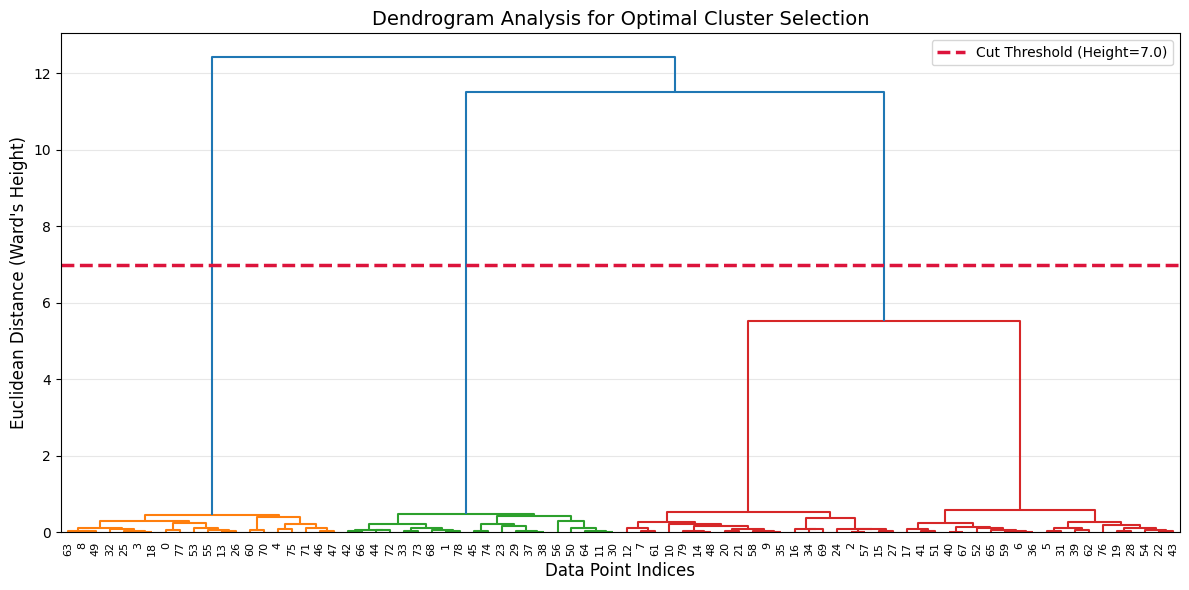

=== HIERARCHICAL SELECTION SUMMARY ===
Dendrogram Threshold cutting gave us: 4 Clusters.
First 15 sample assignments: [3 2 1 3 3 0 0 1 3 1 1 2 1 3 1]


In [4]:
# Topic 135 | Hierarchical Clustering - Dendrograms & Cluster Selection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Dataset Generation (4 Naturally occurring groups simulate kar rahe hain)
X, _ = make_blobs(n_samples=80, centers=4, cluster_std=0.55, random_state=42)

# Preprocessing: Distance metrics ke liye standard scaling lazmi hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------
# STEP 2: Matrix Generation using Ward's Linkage
# ------------------------------------------------------------------
Z = linkage(X_scaled, method="ward")

# ------------------------------------------------------------------
# STEP 3: Plotting Dendrogram with Custom Cut Threshold
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# leaf_rotation aur leaf_font_size x-axis ke labels ko clean karne ke liye hain
dend_plot = dendrogram(Z, leaf_rotation=90, leaf_font_size=8)

# Hum visual analysis ke mutabiq vertical gap dekh kar ek threshold line lagate hain
# Farz karein hum height = 7.0 par cut lagate hain
threshold_height = 7.0
plt.axhline(y=threshold_height, color="crimson", linestyle="--", linewidth=2.5, label=f"Cut Threshold (Height={threshold_height})")

plt.title("Dendrogram Analysis for Optimal Cluster Selection", fontsize=14)
plt.xlabel("Data Point Indices", fontsize=12)
plt.ylabel("Euclidean Distance (Ward's Height)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# STEP 4: Applying Scikit-Learn Model based on Cut Analysis
# ------------------------------------------------------------------
# Agar aap dhyan se dekhein toh threshold line 4 vertical lines ko cut karegi
optimal_k = 4
agg_model = AgglomerativeClustering(n_clusters=optimal_k, metric="euclidean", linkage="ward")
cluster_labels = agg_model.fit_predict(X_scaled)

print("=== HIERARCHICAL SELECTION SUMMARY ===")
print(f"Dendrogram Threshold cutting gave us: {optimal_k} Clusters.")
print(f"First 15 sample assignments: {cluster_labels[:15]}")

In [6]:
# Topic 136 | Hierarchical Clustering - Implementation with Scikit-Learn - Part I
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import cophenet, linkage  # Fixed: imported cophenet instead of cophenetic
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Complex Wholesale Corporate Spending Dataset simulate karein
# 400 clients ka multi-category spending matrix (4 Informative Features)
X_raw, _ = make_blobs(
    n_samples=400, n_features=4, centers=4, cluster_std=0.85, random_state=42
)

columns = ["Fresh_Produce", "Grocery_Spend", "Detergents_Paper", "Delicatessen"]
df_wholesale = pd.DataFrame(X_raw, columns=columns)

print("=== PART I: HIERARCHICAL PRODUCTION PIPELINE START ===")
print(f"Dataset Shape (Rows, Features): {df_wholesale.shape}\n")

# 2. MANDATORY DATA PREPROCESSING (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wholesale)

# 3. COMPUTING DISTANCE MATRIX
actual_distances = pdist(X_scaled)

# ------------------------------------------------------------------
# STEP 4: GRID SEARCH OVER DIFFERENT LINKAGE CRITERIA
# ------------------------------------------------------------------
linkage_methods = ["ward", "complete", "average", "single"]
pipeline_logs = []

print("Running Agglomerative Linkage Matrix Computations...")

for method in linkage_methods:
    # SciPy linkage implementation
    linkage_matrix = linkage(X_scaled, method=method)

    # Cophenet function returns the matrix and the actual cophenetic correlation coefficient
    # We take the first element [0] which is the correlation value
    coph_corr, _ = cophenet(linkage_matrix, actual_distances)

    pipeline_logs.append({"Linkage_Method": method, "Cophenetic_Correlation": coph_corr})

# Results ko display karne ke liye DataFrame banayein
df_linkage_metrics = pd.DataFrame(pipeline_logs)
print("\n--- Pipeline Linkage Evaluation Logs ---")
print(df_linkage_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))





=== PART I: HIERARCHICAL PRODUCTION PIPELINE START ===
Dataset Shape (Rows, Features): (400, 4)

Running Agglomerative Linkage Matrix Computations...

--- Pipeline Linkage Evaluation Logs ---
Linkage_Method  Cophenetic_Correlation
          ward                  0.9781
      complete                  0.9764
       average                  0.9788
        single                  0.9777


=== PART II: HIERARCHICAL SEGMENTATION & AUDIT ===


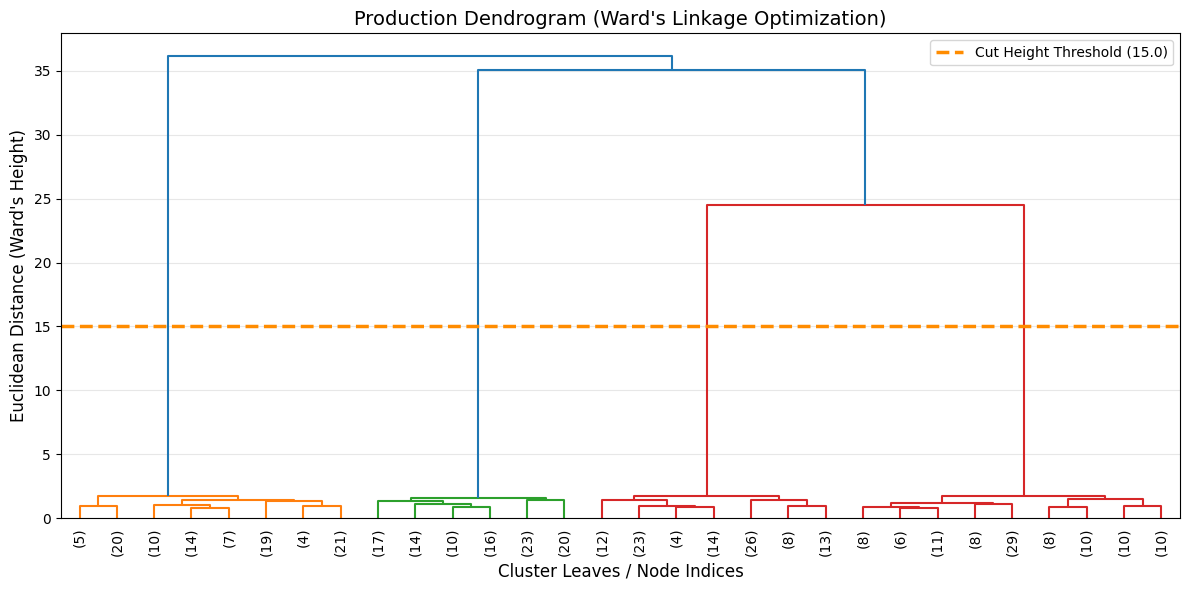


--- Corporate Client Profiles (Mean Expenditure Scale) ---
 Client_Segment  Fresh_Produce  Grocery_Spend  Detergents_Paper  Delicatessen
              0        -6.9486        -6.9384           -8.8373        7.3341
              1         2.2140         4.2333           -9.4829        9.4635
              2        -2.5321         9.0461            4.6410        1.9845
              3         6.6679        -5.6586           -6.3342       -6.3187


In [8]:
# Topic 137 | Hierarchical Clustering - Implementation with Scikit-Learn - Part II
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Part I ka Dataset aur Scaling re-align karein
X_raw, _ = make_blobs(
    n_samples=400, n_features=4, centers=4, cluster_std=0.85, random_state=42
)
columns = ["Fresh_Produce", "Grocery_Spend", "Detergents_Paper", "Delicatessen"]
df_wholesale = pd.DataFrame(X_raw, columns=columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wholesale)

print("=== PART II: HIERARCHICAL SEGMENTATION & AUDIT ===")

# ------------------------------------------------------------------
# STEP 2: SciPy Linkage & Dendrogram Visualization
# ------------------------------------------------------------------
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
# Only showing top levels for clean presentation in production logs
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10)

# Hamari metric calculations ke mutabiq hum Height=15.0 par cut threshold lagate hain
cut_height = 15.0
plt.axhline(
    y=cut_height,
    color="darkorange",
    linestyle="--",
    linewidth=2.5,
    label=f"Cut Height Threshold ({cut_height})",
)

plt.title("Production Dendrogram (Ward's Linkage Optimization)", fontsize=14)
plt.xlabel("Cluster Leaves / Node Indices", fontsize=12)
plt.ylabel("Euclidean Distance (Ward's Height)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# STEP 3: Apply Scikit-Learn Model based on Cut Analysis
# ------------------------------------------------------------------
# Threshold line 4 main vertical stems ko intercept kar rahi hai -> Optimal K = 4
optimal_clusters = 4
agg_model = AgglomerativeClustering(
    n_clusters=optimal_clusters, metric="euclidean", linkage="ward"
)
df_wholesale["Client_Segment"] = agg_model.fit_predict(X_scaled)

# ------------------------------------------------------------------
# STEP 4: CORPORATE CLIENT PROFILING (Group-wise Averages)
# ------------------------------------------------------------------
df_profile = df_wholesale.groupby("Client_Segment").mean().reset_index()

print("\n--- Corporate Client Profiles (Mean Expenditure Scale) ---")
print(
    df_profile.to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

=== PCA DIMENSIONALITY REDUCTION SHURU ===
Original Data Shape: (300, 3) (3 Dimensions)
Transformed Data Shape: (300, 2) (2 Dimensions)

PC1 captures: 85.02% information
PC2 captures: 13.98% information
Total Information Retained: 99.00%


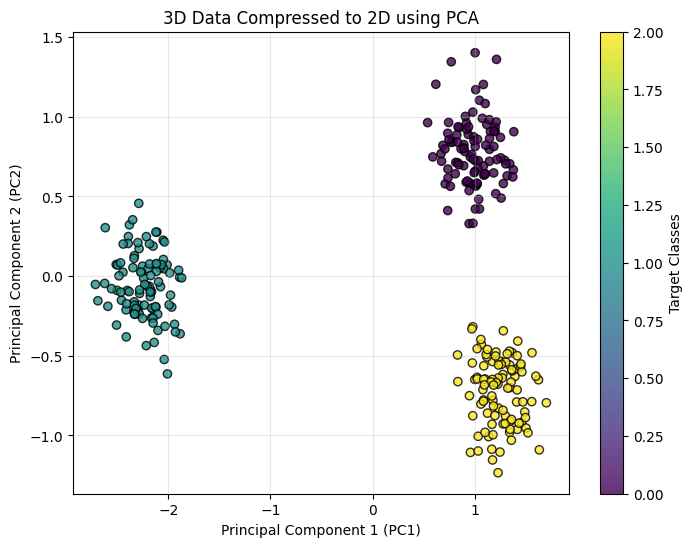

In [9]:
# Topic 138 | Introduction to Principal Component Analysis (PCA)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. 3D Dataset generate karein (3 Features)
X_3D, y = make_blobs(n_samples=300, n_features=3, centers=3, cluster_std=1.0, random_state=42)

# CRITICAL STEP FOR PCA: Standardization
# PCA pure variance aur distances par chalta hai, isliye scaling karna FARZ hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_3D)

print("=== PCA DIMENSIONALITY REDUCTION SHURU ===")
print(f"Original Data Shape: {X_scaled.shape} (3 Dimensions)")

# 2. PCA Initialize aur Fit karein (Target: 2 Dimensions)
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

print(f"Transformed Data Shape: {X_2D.shape} (2 Dimensions)")

# 3. Explained Variance Ratio check karein
# Yeh batata hai ki har PC ne kitne percent information capture ki
explained_variance = pca.explained_variance_ratio_
print(f"\nPC1 captures: {explained_variance[0]*100:.2f}% information")
print(f"PC2 captures: {explained_variance[1]*100:.2f}% information")
print(f"Total Information Retained: {sum(explained_variance)*100:.2f}%")

# 4. Visualizing the Compressed 2D Data
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.8)
plt.title("3D Data Compressed to 2D using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Target Classes')
plt.show()